In [26]:
# 1. Import Libraries


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [27]:
# 2. Load Dataset

df = pd.read_csv(r"D:\Courses\DEPI\Technical\ML\breast-cancer.csv")



X = df.drop("diagnosis", axis=1)   
y = df["diagnosis"]

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)


Shape of X: (569, 31)
Shape of y: (569,)


# 3. Basic EDA

In [28]:
print("\nFirst 5 rows:")


print("\nDataset Info:")


print("\nStatistical Summary:")




First 5 rows:

Dataset Info:

Statistical Summary:


In [29]:
# 4. Check Missing Values
print(X.isnull().sum())

id                         0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


diagnosis
B    357
M    212
Name: count, dtype: int64


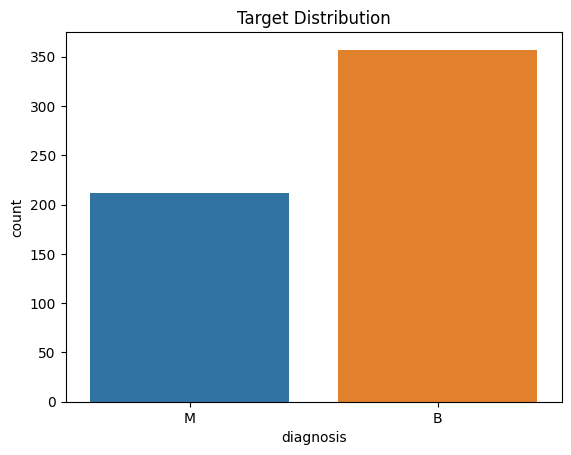

In [30]:
# 5. Target Distribution using value counts and plotting
print(y.value_counts())

import seaborn as sns
sns.countplot(x=y)
plt.title("Target Distribution")
plt.show()

#Univariate Analysis

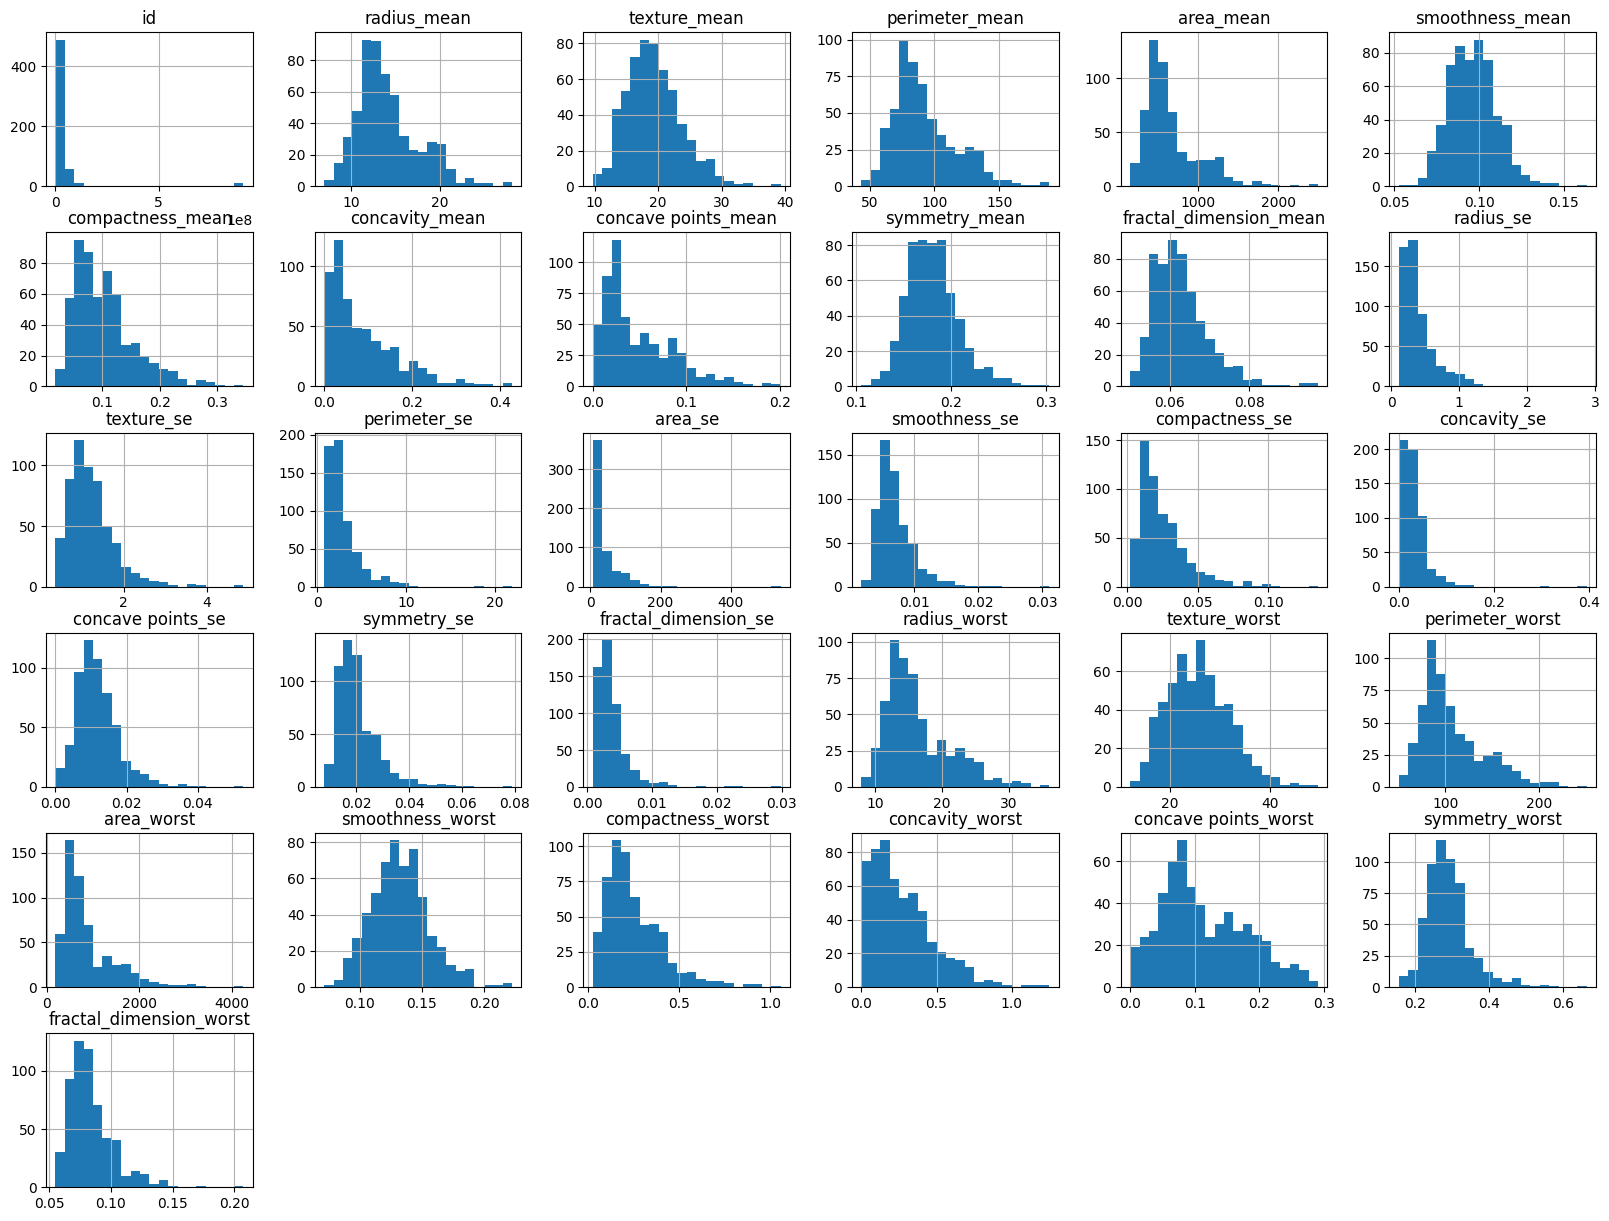

In [31]:
X.hist(figsize=(20,15), bins=20)
plt.show()

Task:

Are the features normally distributed?

Do you see any skewness?

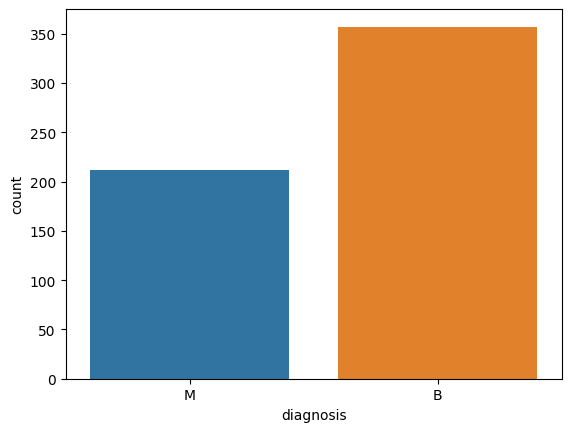

In [32]:
#Visualize Target Distribution
sns.countplot(x=y)
plt.show()

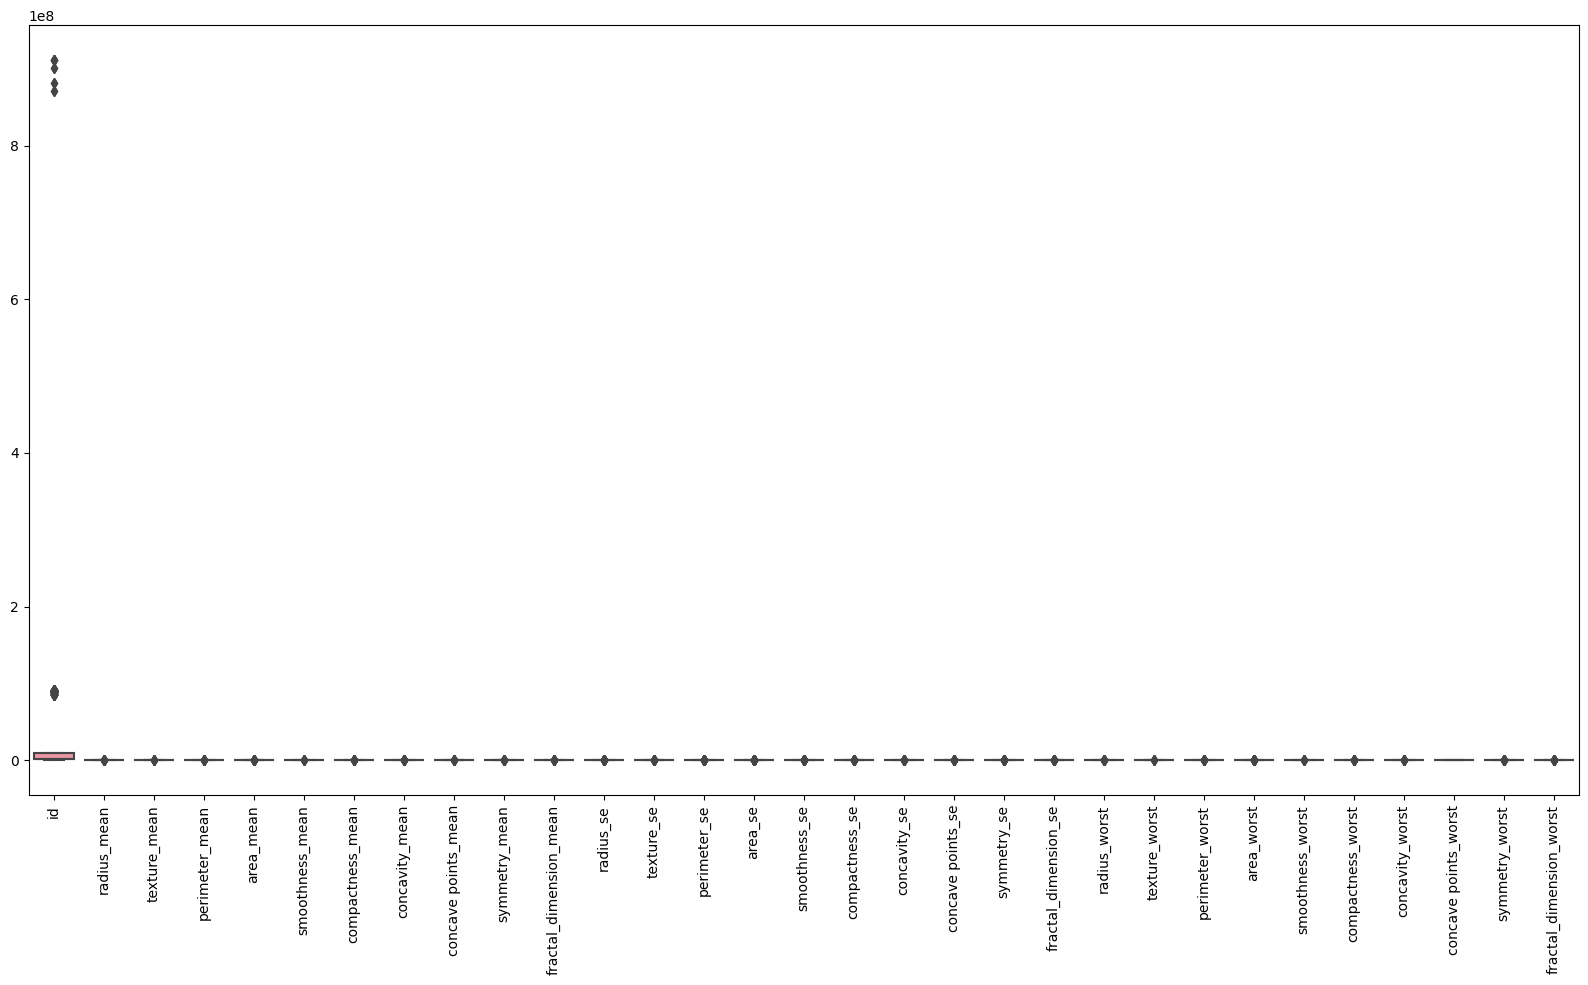

In [33]:
#Detect Outliers using Boxplots
plt.figure(figsize=(20,10))
sns.boxplot(data=X)
plt.xticks(rotation=90)
plt.show()

Task:

Do you notice any outliers?

How might outliers affect the model?


Feature vs Target Relationship

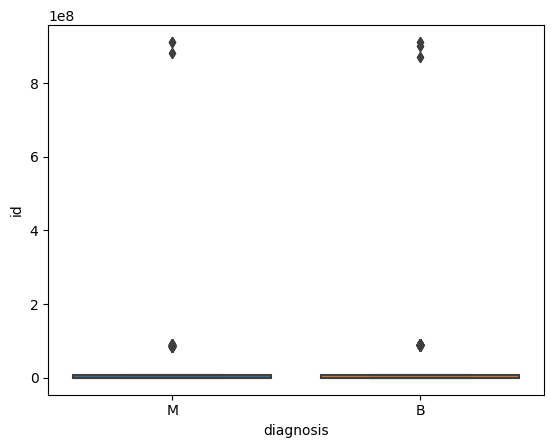

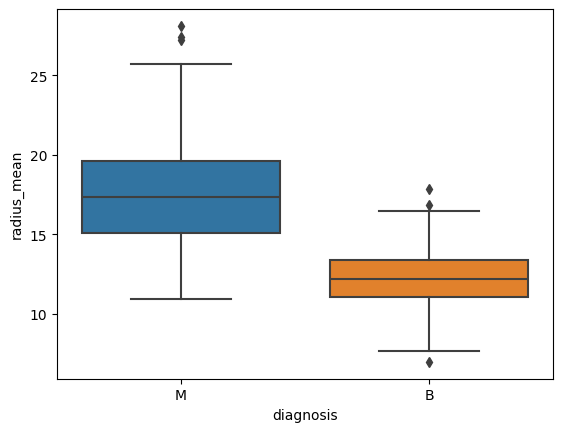

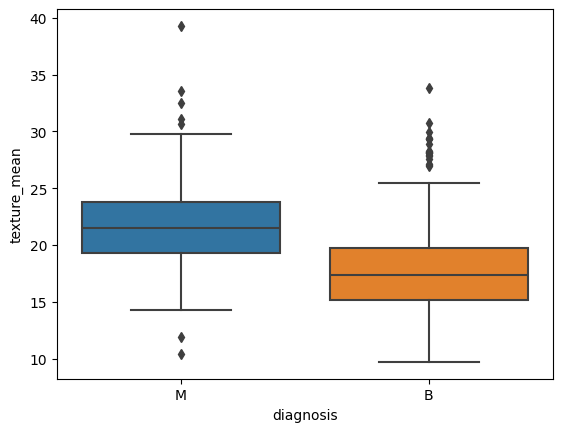

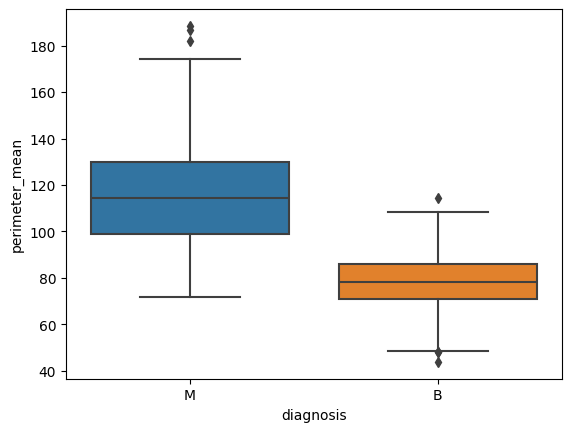

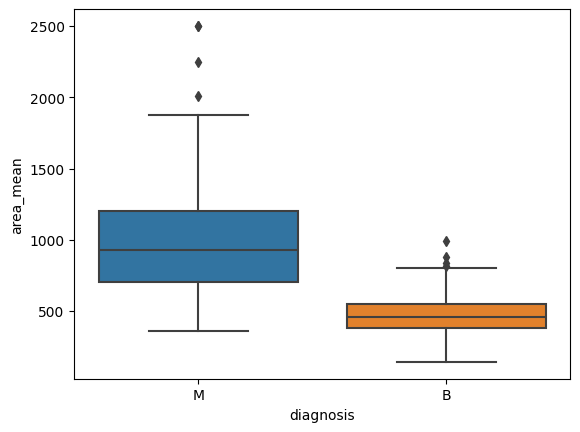

In [34]:
for col in X.columns[:5]:
    sns.boxplot(x=y, y=X[col])
    plt.show()

# Task

Which features clearly separate the classes?

Which features seem less useful?


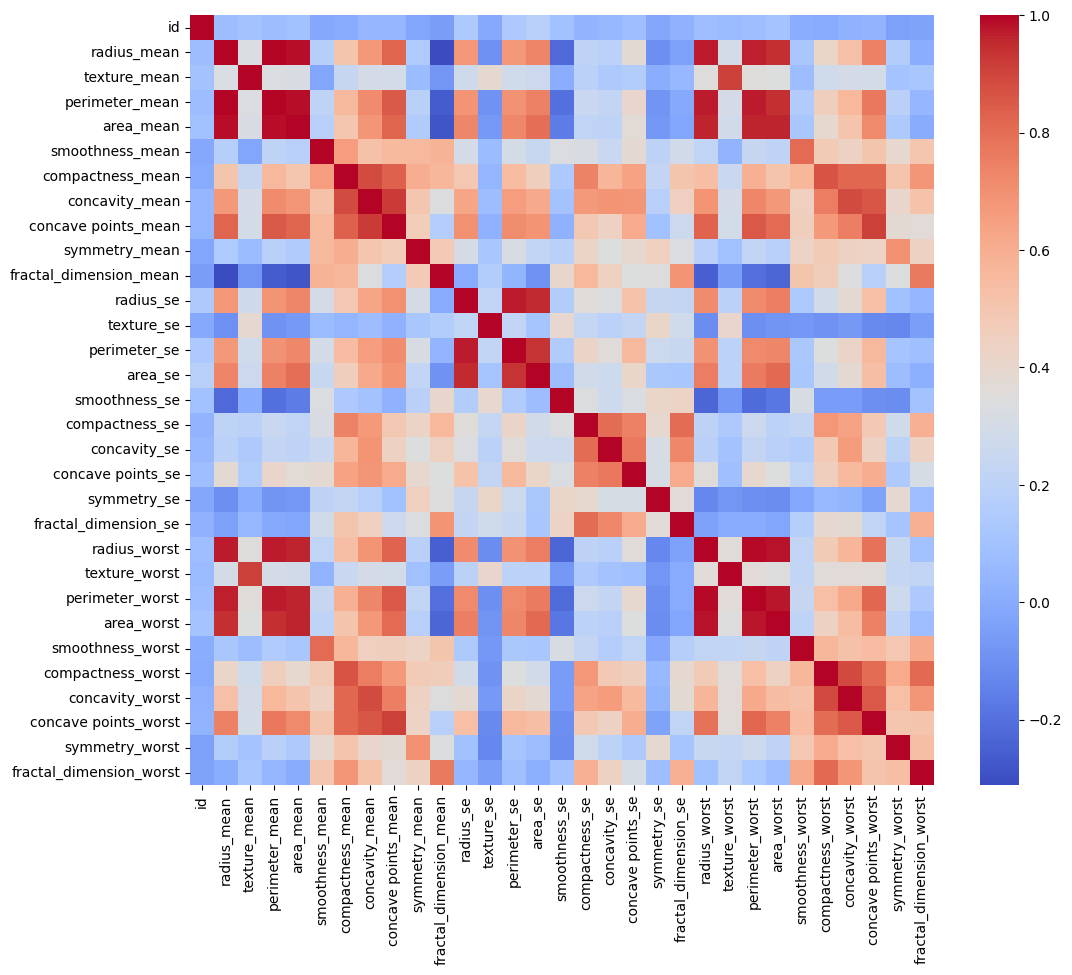

In [35]:
# 6. Correlation Analysis
# plot the correlation map for the features
plt.figure(figsize=(12,10))
sns.heatmap(X.corr(), cmap="coolwarm")
plt.show()

Task:

Do you see clear separation between classes?

Are there linear relationships?

In [36]:
# 7. Feature Selection

# Example: remove highly correlated features

corr = X.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]
X = X.drop(columns=to_drop)

print("Dropped:", to_drop)


Dropped: ['perimeter_mean', 'area_mean', 'concave points_mean', 'perimeter_se', 'area_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'concave points_worst']


# ======================================
# 8. Train-Test Split
# ====================================

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44)

# ======================================
# 9. Feature Scaling
# ======================================

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Feature Scaling Impact

In [39]:
print("Before Scaling (example):")
print(X.head())

print("After Scaling:")
print(X_train[:5])

Before Scaling (example):
         id  radius_mean  texture_mean  smoothness_mean  compactness_mean  \
0    842302        17.99         10.38          0.11840           0.27760   
1    842517        20.57         17.77          0.08474           0.07864   
2  84300903        19.69         21.25          0.10960           0.15990   
3  84348301        11.42         20.38          0.14250           0.28390   
4  84358402        20.29         14.34          0.10030           0.13280   

   concavity_mean  symmetry_mean  fractal_dimension_mean  radius_se  \
0          0.3001         0.2419                 0.07871     1.0950   
1          0.0869         0.1812                 0.05667     0.5435   
2          0.1974         0.2069                 0.05999     0.7456   
3          0.2414         0.2597                 0.09744     0.4956   
4          0.1980         0.1809                 0.05883     0.7572   

   texture_se  ...  compactness_se  concavity_se  concave points_se  \
0      0.9053

Task:

What changed after scaling?

Why is scaling important for Logistic Regression?

# Final Reflection Questions



** Answer the following:**

Which features are most useful for prediction? 
radius_mean, perimeter_mean, area_mean


Did you find any redundant features?
correlated features that is removed.

Is scaling necessary? Why? 
Yes , improve performance


Do you think Logistic Regression is suitable for this dataset?
yes, as it's binary classification problem

## put ur answwer here



*   List item
*   List item



# ======================================
# 10. Train Model
# ======================================

In [40]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

# ======================================
# 11. Prediction
# ======================================

In [41]:
y_pred = model.predict(X_test)

# ======================================
# 12. Evaluation
# ======================================

In [42]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))

Accuracy: 0.9912280701754386

Confusion Matrix:
 [[75  0]
 [ 1 38]]

Report:
               precision    recall  f1-score   support

           B       0.99      1.00      0.99        75
           M       1.00      0.97      0.99        39

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



# ======================================
# 13. Student Tasks
# ======================================
# 1. Try model without removing correlated features
# 2. Try different test sizes (0.3, 0.25)
# 3. Print model coefficients
# 4. Try another model (KNN  and choose the best k for it )
# 5. Plot ROC Curve


# 1

In [43]:
X_full = df.drop("diagnosis", axis=1)
y = df["diagnosis"].map({'M': 1, 'B': 0})

X_train, X_test, y_train, y_test = train_test_split(X_full, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train, y_train)

print("Accuracy", model.score(X_test, y_test))

Accuracy 0.9736842105263158


# 2

In [44]:
for size in [0.3, 0.25]:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=size, random_state=42)
    
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    model = LogisticRegression()
    model.fit(X_train, y_train)
    
    print(f"Test size {size} → Accuracy:", model.score(X_test, y_test))

Test size 0.3 → Accuracy: 0.9766081871345029
Test size 0.25 → Accuracy: 0.972027972027972


# 3

In [45]:
model = LogisticRegression()
model.fit(X_train, y_train)

coeff_df = pd.DataFrame(model.coef_[0], index=X.columns, columns=["Coefficient"])
print(coeff_df.sort_values(by="Coefficient", ascending=False))

                         Coefficient
radius_mean                 2.102769
radius_se                   2.013482
symmetry_worst              1.503404
concavity_mean              1.429531
concavity_worst             1.278464
texture_mean                1.192871
concave points_se           0.841462
smoothness_worst            0.776924
smoothness_mean             0.247140
fractal_dimension_worst     0.230774
texture_se                  0.180090
id                          0.172710
compactness_worst           0.052768
smoothness_se              -0.087327
concavity_se               -0.177772
compactness_mean           -0.212993
symmetry_mean              -0.322986
fractal_dimension_mean     -0.576116
compactness_se             -0.621265
symmetry_se                -0.811227
fractal_dimension_se       -0.862988


# 4

In [46]:
scores = []

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    scores.append(knn.score(X_test, y_test))

best_k = scores.index(max(scores)) + 1
print("Best K:", best_k)
print("Best Accuracy:", max(scores))

Best K: 12
Best Accuracy: 0.972027972027972


# 5

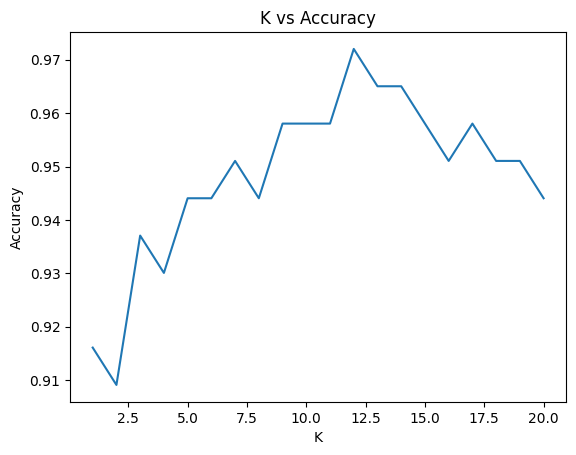

In [47]:
plt.plot(range(1,21), scores)
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy")
plt.show()

# 6

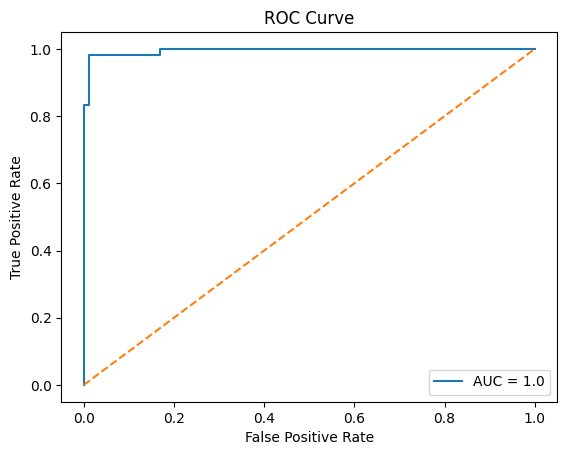

In [48]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = " + str(round(roc_auc,2)))
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [51]:
import pickle

pickle.dump(model, open('breast_cancer_model.pkl', 'wb'))

In [50]:
whos

Variable                Type                    Data/Info
---------------------------------------------------------
KNeighborsClassifier    ABCMeta                 <class 'sklearn.neighbors<...>on.KNeighborsClassifier'>
LogisticRegression      type                    <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
StandardScaler          type                    <class 'sklearn.preproces<...>ng._data.StandardScaler'>
X                       DataFrame                          id  radius_mea<...>\n[569 rows x 21 columns]
X_full                  DataFrame                          id  radius_mea<...>\n[569 rows x 31 columns]
X_test                  ndarray                 143x21: 3003 elems, type `float64`, 24024 bytes
X_train                 ndarray                 426x21: 8946 elems, type `float64`, 71568 bytes
accuracy_score          function                <function accuracy_score at 0x0000024B2DFCED40>
auc                     function                <function auc at 0x0000024B2